In [1]:
import os

os.makedirs("analytics", exist_ok=True)

print("Analytics folder created")

Analytics folder created


In [2]:
!pip install -q imbalanced-learn

In [3]:
import pandas as pd
import numpy as np

import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV

from sklearn.preprocessing import StandardScaler, OneHotEncoder

from sklearn.compose import ColumnTransformer

from sklearn.pipeline import Pipeline

from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression, LinearRegression

from sklearn.tree import DecisionTreeClassifier, plot_tree

from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_curve,
    roc_auc_score,
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

import joblib
import warnings

warnings.filterwarnings("ignore")

print("All libraries imported successfully")

All libraries imported successfully


In [4]:
sns.load_dataset('titanic')

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,0,2,male,27.0,0,0,13.0000,S,Second,man,True,NaN,Southampton,no,True
887,1,1,female,19.0,0,0,30.0000,S,First,woman,False,B,Southampton,yes,True
888,0,3,female,NaN,1,2,23.4500,S,Third,woman,False,NaN,Southampton,no,False
889,1,1,male,26.0,0,0,30.0000,C,First,man,True,C,Cherbourg,yes,True


In [5]:
df = sns.load_dataset("titanic")

print("Dataset loaded successfully")
print("Shape:", df.shape)

Dataset loaded successfully
Shape: (891, 15)


In [6]:
df.to_csv("analytics/titanic.csv", index=False)

print("Saved:")
print("analytics/titanic.csv")

Saved:
analytics/titanic.csv


In [8]:
pd.read_csv("analytics/titanic.csv")

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,0,2,male,27.0,0,0,13.0000,S,Second,man,True,NaN,Southampton,no,True
887,1,1,female,19.0,0,0,30.0000,S,First,woman,False,B,Southampton,yes,True
888,0,3,female,NaN,1,2,23.4500,S,Third,woman,False,NaN,Southampton,no,False
889,1,1,male,26.0,0,0,30.0000,C,First,man,True,C,Cherbourg,yes,True


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB


In [10]:
df.describe()

,survived,pclass,age,sibsp,parch,fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [11]:
print("Dataset shape:", df.shape)

Dataset shape: (891, 15)


In [12]:
missing = df.isnull().sum()
missing_percent = (df.isnull().mean() * 100)

missing_report = pd.DataFrame({
    "Missing Count": missing,
    "Missing Percentage": missing_percent
})

missing_report = missing_report[missing_report["Missing Count"] > 0]

print(missing_report)

             Missing Count  Missing Percentage
age                    177           19.865320
embarked                 2            0.224467
deck                   688           77.216611
embark_town              2            0.224467


In [13]:
missing_report = missing_report.sort_values(
    "Missing Percentage",
    ascending=False
)

missing_report

,Missing Count,Missing Percentage
deck,688,77.216611
age,177,19.865320
embarked,2,0.224467
embark_town,2,0.224467


In [14]:
df_clean = df.copy()

# Drop deck because it has a very high percentage of missing values
df_clean = df_clean.drop(columns=["deck"])

# Drop rows where embarked is missing
df_clean = df_clean.dropna(subset=["embarked"])

# Impute age using median
df_clean["age"] = df_clean["age"].fillna(df_clean["age"].median())

print("Cleaned dataset shape:", df_clean.shape)

Cleaned dataset shape: (889, 14)


In [15]:
print(df_clean.isnull().sum())

survived       0
pclass         0
sex            0
age            0
sibsp          0
parch          0
fare           0
embarked       0
class          0
who            0
adult_male     0
embark_town    0
alive          0
alone          0
dtype: int64


In [16]:
df_clean.to_csv(
    "analytics/titanic_clean.csv",
    index=False
)

print("Cleaned dataset saved.")

Cleaned dataset saved.


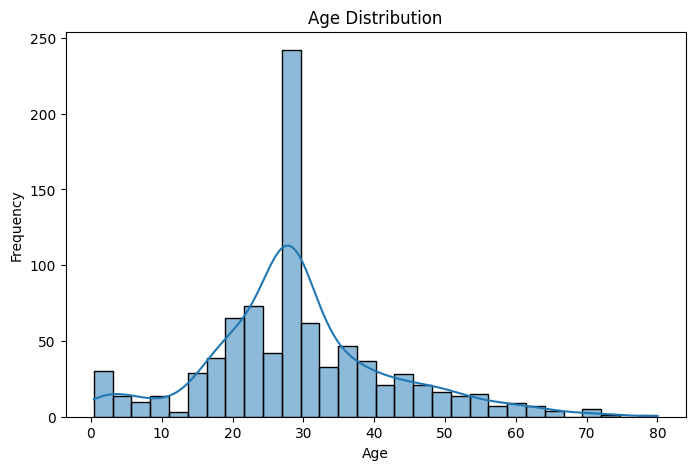

In [17]:
plt.figure(figsize=(8, 5))

sns.histplot(
    df_clean["age"],
    bins=30,
    kde=True
)

plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Frequency")

plt.show()

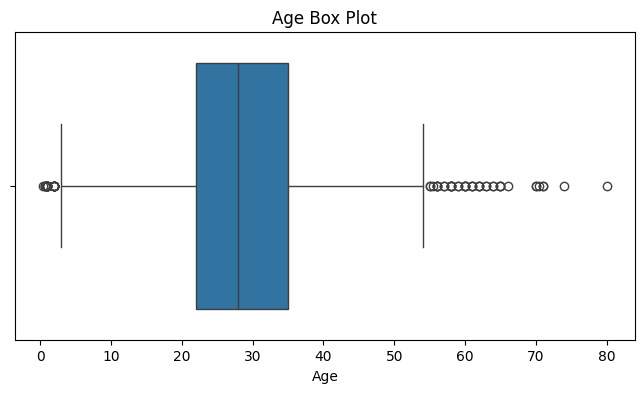

In [18]:
plt.figure(figsize=(8, 4))

sns.boxplot(
    x=df_clean["age"]
)

plt.title("Age Box Plot")
plt.xlabel("Age")

plt.show()

In [19]:
Q1_age = df_clean["age"].quantile(0.25)
Q3_age = df_clean["age"].quantile(0.75)

IQR_age = Q3_age - Q1_age

lower_age = Q1_age - 1.5 * IQR_age
upper_age = Q3_age + 1.5 * IQR_age

age_outliers = df_clean[
    (df_clean["age"] < lower_age) |
    (df_clean["age"] > upper_age)
]

print("Age Q1:", Q1_age)
print("Age Q3:", Q3_age)
print("Age IQR:", IQR_age)
print("Lower limit:", lower_age)
print("Upper limit:", upper_age)
print("Number of age outliers:", len(age_outliers))

Age Q1: 22.0
Age Q3: 35.0
Age IQR: 13.0
Lower limit: 2.5
Upper limit: 54.5
Number of age outliers: 65


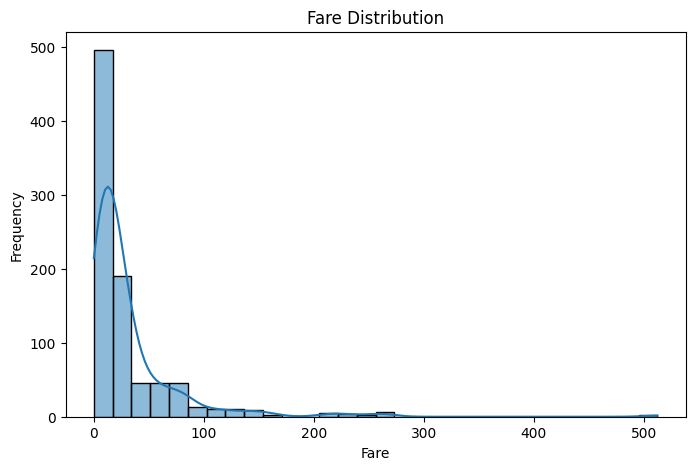

In [20]:
plt.figure(figsize=(8, 5))

sns.histplot(
    df_clean["fare"],
    bins=30,
    kde=True
)

plt.title("Fare Distribution")
plt.xlabel("Fare")
plt.ylabel("Frequency")

plt.show()

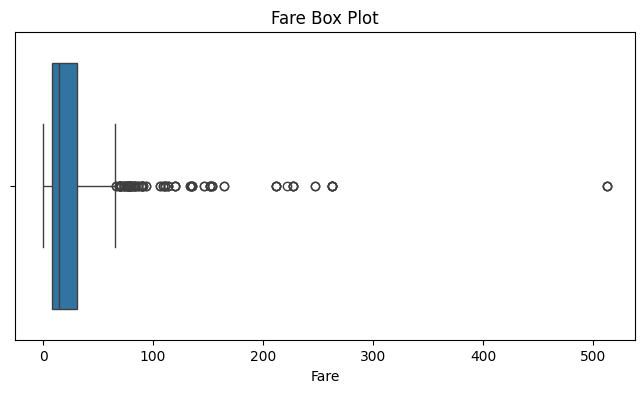

In [21]:
plt.figure(figsize=(8, 4))

sns.boxplot(
    x=df_clean["fare"]
)

plt.title("Fare Box Plot")
plt.xlabel("Fare")

plt.show()

In [22]:
Q1_fare = df_clean["fare"].quantile(0.25)
Q3_fare = df_clean["fare"].quantile(0.75)

IQR_fare = Q3_fare - Q1_fare

lower_fare = Q1_fare - 1.5 * IQR_fare
upper_fare = Q3_fare + 1.5 * IQR_fare

fare_outliers = df_clean[
    (df_clean["fare"] < lower_fare) |
    (df_clean["fare"] > upper_fare)
]

print("Fare Q1:", Q1_fare)
print("Fare Q3:", Q3_fare)
print("Fare IQR:", IQR_fare)
print("Lower limit:", lower_fare)
print("Upper limit:", upper_fare)
print("Number of fare outliers:", len(fare_outliers))

Fare Q1: 7.8958
Fare Q3: 31.0
Fare IQR: 23.1042
Lower limit: -26.7605
Upper limit: 65.6563
Number of fare outliers: 114


In [23]:
fare_mean = df_clean["fare"].mean()
fare_median = df_clean["fare"].median()
fare_mode = df_clean["fare"].mode()[0]

print("Fare Mean:", fare_mean)
print("Fare Median:", fare_median)
print("Fare Mode:", fare_mode)

Fare Mean: 32.09668087739032
Fare Median: 14.4542
Fare Mode: 8.05


In [25]:
survival_by_sex = (
    df_clean
    .groupby("sex")["survived"]
    .mean()
    .reset_index()
    .rename(columns={"survived": "survival_rate"})
)

survival_by_sex["survival_rate"] *= 100

survival_by_sex

,sex,survival_rate
0,female,74.038462
1,male,18.890815


In [27]:
survival_by_class = (
    df_clean
    .groupby("pclass")["survived"]
    .mean()
    .reset_index()
    .rename(columns={"survived": "survival_rate"})
)

survival_by_class["survival_rate"] *= 100

survival_by_class

,pclass,survival_rate
0,1,62.616822
1,2,47.282609
2,3,24.236253


In [29]:
survival_by_sex_class = (
    df_clean
    .groupby(["sex", "pclass"])["survived"]
    .mean()
    .reset_index()
    .rename(columns={"survived": "survival_rate"})
)

survival_by_sex_class["survival_rate"] *= 100

survival_by_sex_class

,sex,pclass,survival_rate
0,female,1,96.739130
1,female,2,92.105263
2,female,3,50.000000
3,male,1,36.885246
4,male,2,15.740741
5,male,3,13.544669


In [30]:
female_first_class = df_clean[
    (df_clean["sex"] == "female") &
    (df_clean["pclass"] == 1)
]

female_first_class_survival = female_first_class["survived"].mean()

print(
    "Female first-class survival rate:",
    female_first_class_survival * 100,
    "%"
)

Female first-class survival rate: 96.73913043478261 %


In [31]:
male_or_third_class = df_clean[
    (df_clean["sex"] == "male") |
    (df_clean["pclass"] == 3)
]

print("Rows matching condition:", len(male_or_third_class))

Rows matching condition: 721


In [33]:
correlation_columns = [
    "survived",
    "pclass",
    "age",
    "sibsp",
    "parch",
    "fare"
]

corr_matrix = df_clean[correlation_columns].corr()

corr_matrix

,survived,pclass,age,sibsp,parch,fare
survived,1.000000,-0.335549,-0.069822,-0.034040,0.083151,0.255290
pclass,-0.335549,1.000000,-0.336512,0.081656,0.016824,-0.548193
age,-0.069822,-0.336512,1.000000,-0.232543,-0.171485,0.093707
sibsp,-0.034040,0.081656,-0.232543,1.000000,0.414542,0.160887
parch,0.083151,0.016824,-0.171485,0.414542,1.000000,0.217532
fare,0.255290,-0.548193,0.093707,0.160887,0.217532,1.000000


In [34]:
corr_pairs = []

for i in range(len(correlation_columns)):
    for j in range(i + 1, len(correlation_columns)):

        col1 = correlation_columns[i]
        col2 = correlation_columns[j]

        correlation = corr_matrix.loc[col1, col2]

        corr_pairs.append(
            (col1, col2, correlation, abs(correlation))
        )

corr_pairs_sorted = sorted(
    corr_pairs,
    key=lambda x: x[3],
    reverse=True
)

print("Two strongest correlations:")

for pair in corr_pairs_sorted[:2]:
    print(
        pair[0],
        "<->",
        pair[1],
        ":",
        round(pair[2], 4)
    )

Two strongest correlations:
pclass <-> fare : -0.5482
sibsp <-> parch : 0.4145


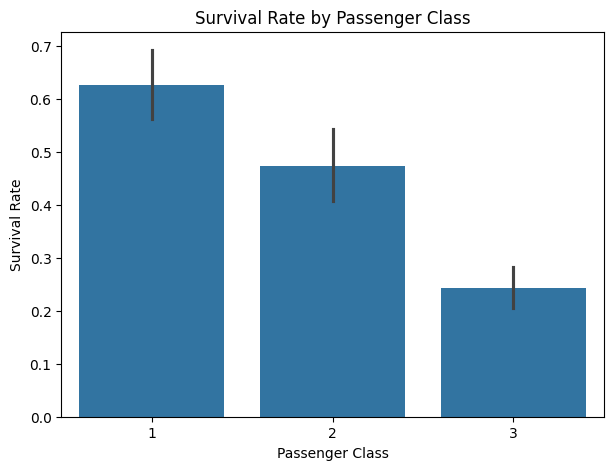

In [35]:
plt.figure(figsize=(7, 5))

sns.barplot(
    data=df_clean,
    x="pclass",
    y="survived"
)

plt.title("Survival Rate by Passenger Class")
plt.ylabel("Survival Rate")
plt.xlabel("Passenger Class")

plt.show()

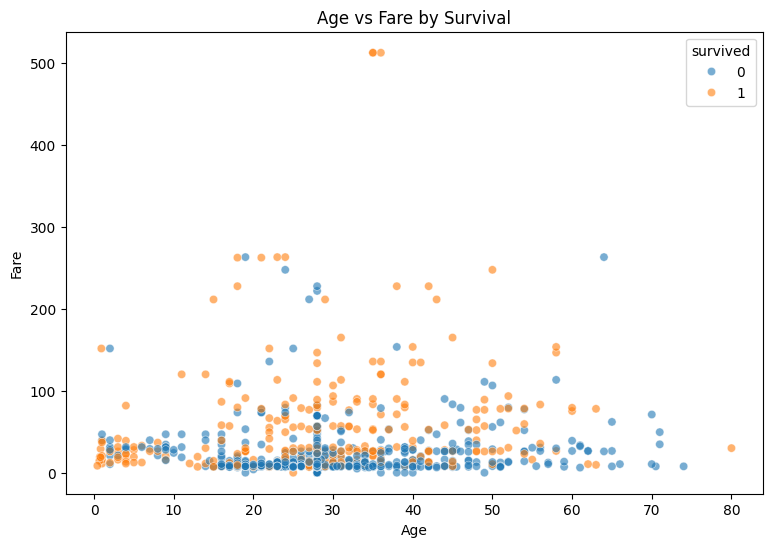

In [36]:
plt.figure(figsize=(9, 6))

sns.scatterplot(
    data=df_clean,
    x="age",
    y="fare",
    hue="survived",
    alpha=0.6
)

plt.title("Age vs Fare by Survival")
plt.xlabel("Age")
plt.ylabel("Fare")

plt.show()

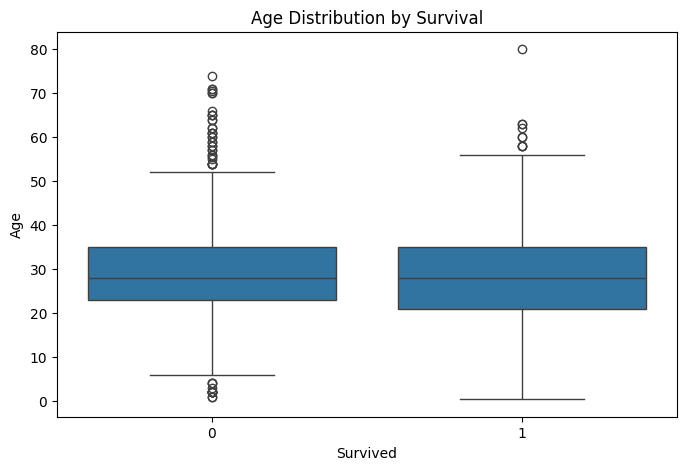

In [37]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df_clean,
    x="survived",
    y="age"
)

plt.title("Age Distribution by Survival")
plt.xlabel("Survived")
plt.ylabel("Age")

plt.show()

In [40]:
df_standardized = df_clean.copy()

In [42]:
scaler_eda = StandardScaler()

df_standardized[["age_z", "fare_z"]] = scaler_eda.fit_transform(
    df_standardized[["age", "fare"]]
)

In [43]:
print("Original Age")
print("Mean:", df_clean["age"].mean())
print("Std:", df_clean["age"].std())

print("\nStandardized Age")
print("Mean:", df_standardized["age_z"].mean())
print("Std:", df_standardized["age_z"].std())

print("\nOriginal Fare")
print("Mean:", df_clean["fare"].mean())
print("Std:", df_clean["fare"].std())

print("\nStandardized Fare")
print("Mean:", df_standardized["fare_z"].mean())
print("Std:", df_standardized["fare_z"].std())

Original Age
Mean: 29.315151856017994
Std: 12.984932293690774

Standardized Age
Mean: 2.717486278497571e-16
Std: 1.000562904632249

Original Fare
Mean: 32.09668087739032
Std: 49.69750431670801

Standardized Fare
Mean: 1.3987061727561027e-16
Std: 1.0005629046322495


In [44]:
model_df = df_clean.copy()

In [45]:
X = model_df.drop(columns=["survived"])
y = model_df["survived"]

In [46]:
print(y.value_counts())
print()
print(y.value_counts(normalize=True) * 100)

survived
0    549
1    340
Name: count, dtype: int64

survived
0    61.754781
1    38.245219
Name: proportion, dtype: float64


In [47]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [48]:
print("Training shape:", X_train.shape)
print("Testing shape:", X_test.shape)

print("\nTraining class distribution:")
print(y_train.value_counts(normalize=True))

print("\nTesting class distribution:")
print(y_test.value_counts(normalize=True))

Training shape: (711, 13)
Testing shape: (178, 13)

Training class distribution:
survived
0    0.61744
1    0.38256
Name: proportion, dtype: float64

Testing class distribution:
survived
0    0.617978
1    0.382022
Name: proportion, dtype: float64


In [49]:
categorical_features = [
    "sex",
    "embarked"
]

In [50]:
numeric_features = [
    "pclass",
    "age",
    "sibsp",
    "parch",
    "fare"
]

In [51]:
numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)

categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        (
            "encoder",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False
            )
        )
    ]
)

In [53]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "numeric",
            numeric_transformer,
            numeric_features
        ),
        (
            "categorical",
            categorical_transformer,
            categorical_features
        )
    ]
)

In [54]:
logistic_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            LogisticRegression(max_iter=1000)
        )
    ]
)

logistic_pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('numeric',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['pclass', 'age', 'sibsp',
                                                   'parch', 'fare']),
                                                 ('categorical',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  ['sex', 'embarked'])])),
                ('classifier', LogisticRegression(max_iter=1000))])

In [55]:
y_pred_lr = logistic_pipeline.predict(X_test)
y_prob_lr = logistic_pipeline.predict_proba(X_test)[:, 1]

In [56]:
tree_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            DecisionTreeClassifier(
                random_state=42,
                max_depth=5
            )
        )
    ]
)

tree_pipeline.fit(X_train, y_train)

y_pred_tree = tree_pipeline.predict(X_test)
y_prob_tree = tree_pipeline.predict_proba(X_test)[:, 1]

In [57]:
rf_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            RandomForestClassifier(
                n_estimators=200,
                random_state=42,
                oob_score=True
            )
        )
    ]
)

rf_pipeline.fit(X_train, y_train)

y_pred_rf = rf_pipeline.predict(X_test)
y_prob_rf = rf_pipeline.predict_proba(X_test)[:, 1]

In [59]:
def evaluate_model(name, y_true, y_pred, y_prob):

    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred)
    recall = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    auc = roc_auc_score(y_true, y_prob)

    cm = confusion_matrix(y_true, y_pred)

    print("=" * 50)
    print(name)
    print("=" * 50)

    print("Confusion Matrix:")
    print(cm)

    print("\nAccuracy:", accuracy)
    print("Precision:", precision)
    print("Recall:", recall)
    print("F1:", f1)
    print("AUC:", auc)

    return {
        "Model": name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1": f1,
        "AUC": auc
    }

In [60]:
results = []

results.append(
    evaluate_model(
        "Logistic Regression",
        y_test,
        y_pred_lr,
        y_prob_lr
    )
)

results.append(
    evaluate_model(
        "Decision Tree",
        y_test,
        y_pred_tree,
        y_prob_tree
    )
)

results.append(
    evaluate_model(
        "Random Forest",
        y_test,
        y_pred_rf,
        y_prob_rf
    )
)

Logistic Regression
Confusion Matrix:
[[97 13]
 [21 47]]

Accuracy: 0.8089887640449438
Precision: 0.7833333333333333
Recall: 0.6911764705882353
F1: 0.734375
AUC: 0.8609625668449199
Decision Tree
Confusion Matrix:
[[98 12]
 [30 38]]

Accuracy: 0.7640449438202247
Precision: 0.76
Recall: 0.5588235294117647
F1: 0.6440677966101694
AUC: 0.8373663101604277
Random Forest
Confusion Matrix:
[[95 15]
 [19 49]]

Accuracy: 0.8089887640449438
Precision: 0.765625
Recall: 0.7205882352941176
F1: 0.7424242424242424
AUC: 0.8195855614973262


In [61]:
classification_results = pd.DataFrame(results)

classification_results

,Model,Accuracy,Precision,Recall,F1,AUC
0,Logistic Regression,0.808989,0.783333,0.691176,0.734375,0.860963
1,Decision Tree,0.764045,0.760000,0.558824,0.644068,0.837366
2,Random Forest,0.808989,0.765625,0.720588,0.742424,0.819586


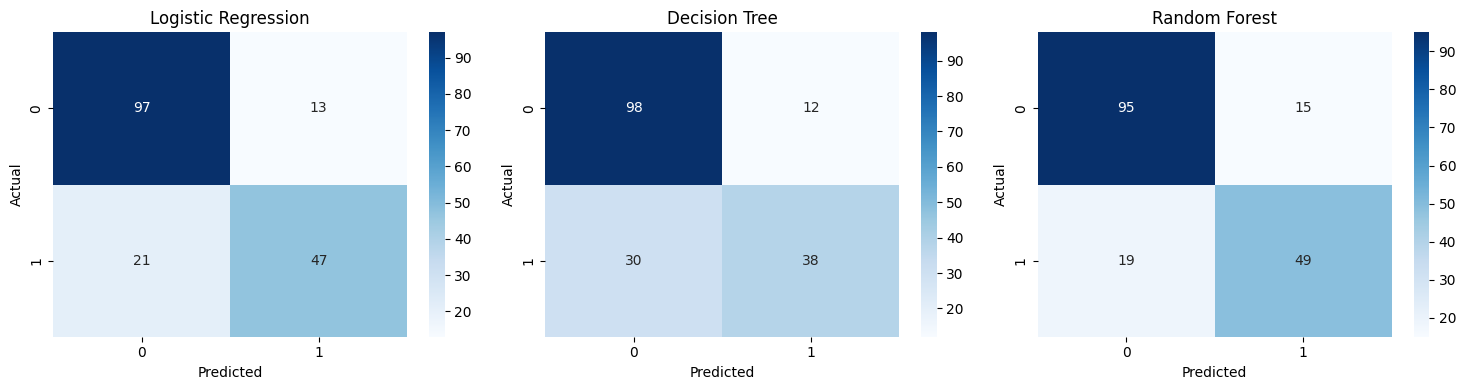

In [62]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

models = [
    ("Logistic Regression", y_pred_lr),
    ("Decision Tree", y_pred_tree),
    ("Random Forest", y_pred_rf)
]

for ax, (name, predictions) in zip(axes, models):

    cm = confusion_matrix(y_test, predictions)

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        ax=ax,
        cmap="Blues"
    )

    ax.set_title(name)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")

plt.tight_layout()
plt.show()

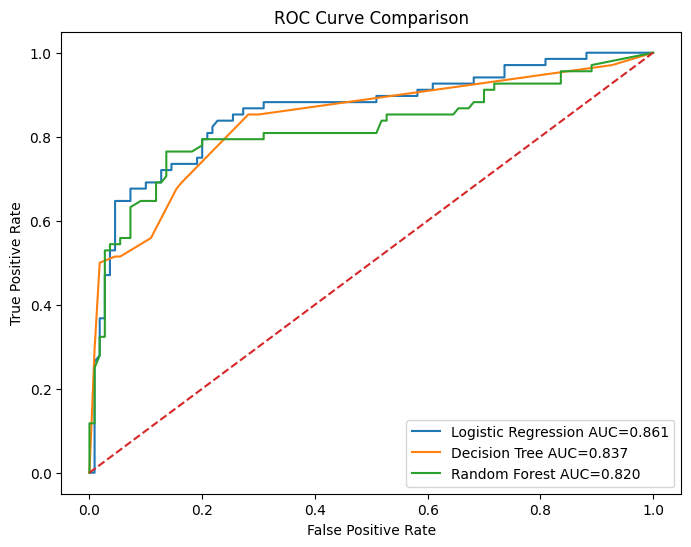

In [63]:
plt.figure(figsize=(8, 6))

fpr_lr, tpr_lr, _ = roc_curve(y_test, y_prob_lr)
fpr_tree, tpr_tree, _ = roc_curve(y_test, y_prob_tree)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)

plt.plot(
    fpr_lr,
    tpr_lr,
    label=f"Logistic Regression AUC={roc_auc_score(y_test, y_prob_lr):.3f}"
)

plt.plot(
    fpr_tree,
    tpr_tree,
    label=f"Decision Tree AUC={roc_auc_score(y_test, y_prob_tree):.3f}"
)

plt.plot(
    fpr_rf,
    tpr_rf,
    label=f"Random Forest AUC={roc_auc_score(y_test, y_prob_rf):.3f}"
)

plt.plot([0, 1], [0, 1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")

plt.legend()

plt.show()

In [64]:
feature_names = (
    numeric_features +
    list(
        tree_pipeline
        .named_steps["preprocessor"]
        .named_transformers_["categorical"]
        .named_steps["encoder"]
        .get_feature_names_out(categorical_features)
    )
)

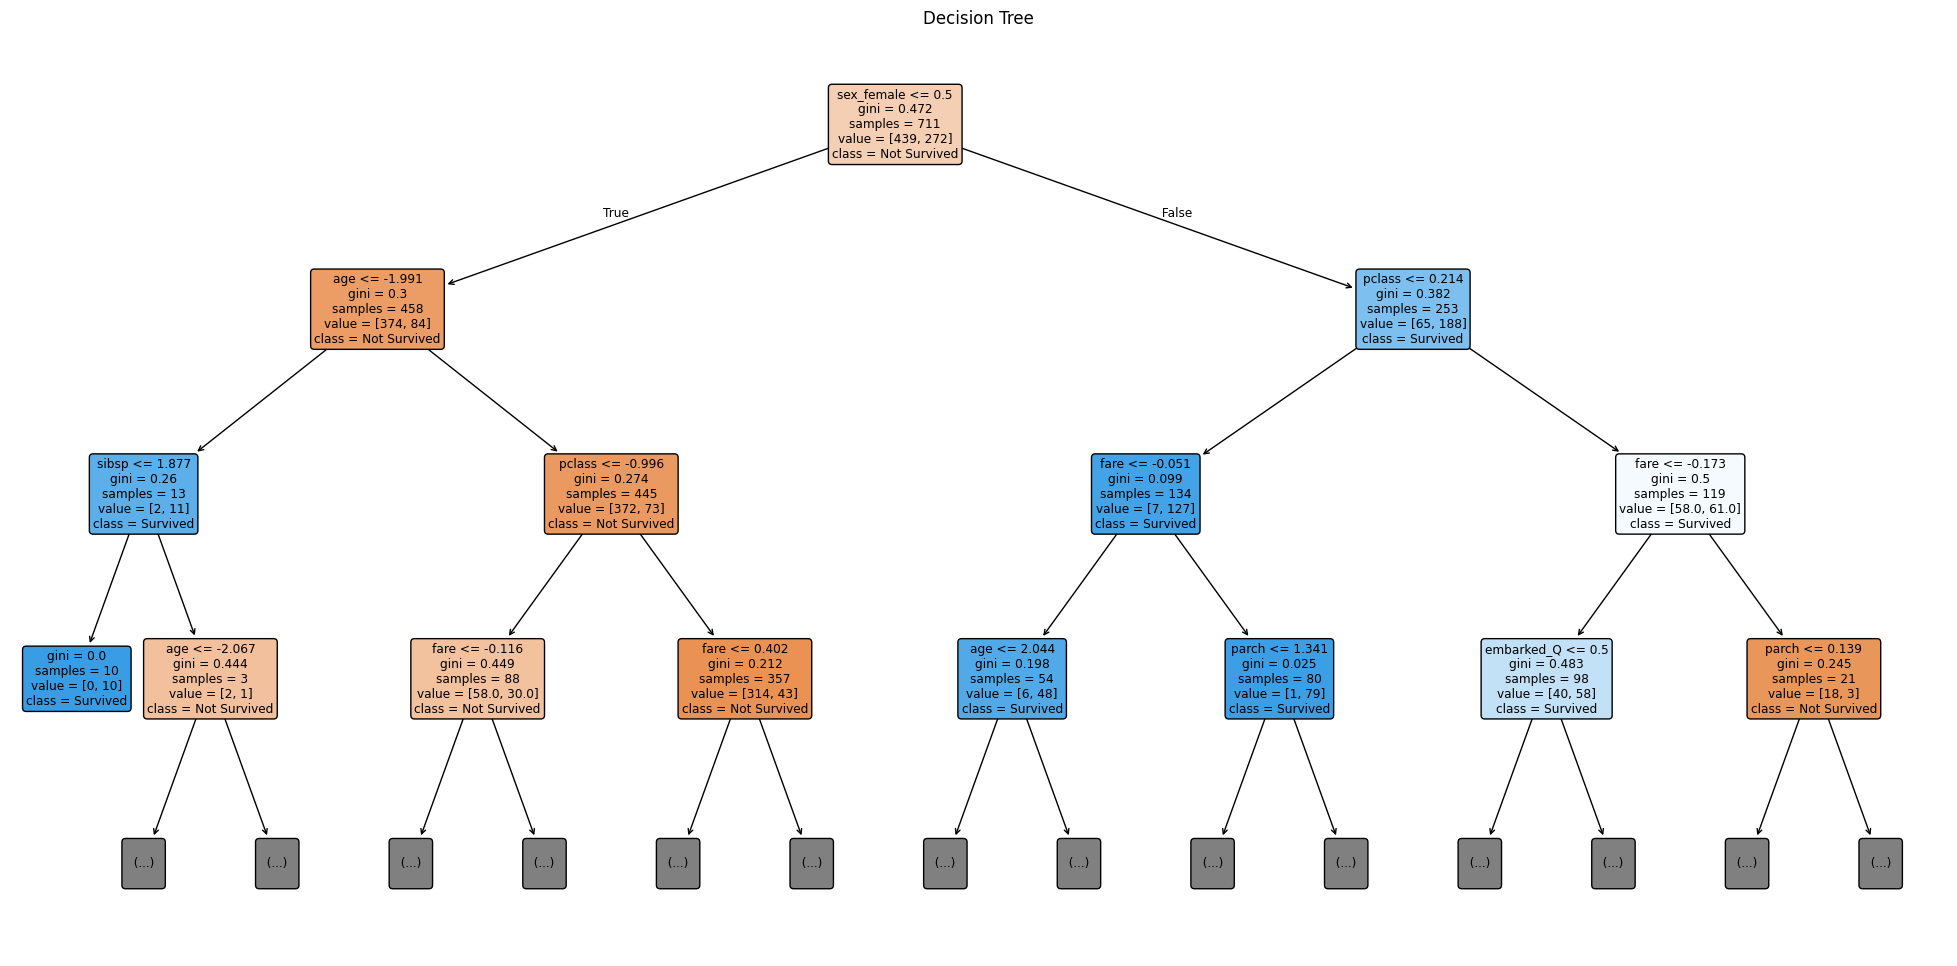

In [65]:
tree_model = tree_pipeline.named_steps["classifier"]

plt.figure(figsize=(25, 12))

plot_tree(
    tree_model,
    feature_names=feature_names,
    class_names=["Not Survived", "Survived"],
    filled=True,
    rounded=True,
    max_depth=3
)

plt.title("Decision Tree")
plt.show()

In [66]:
balance = pd.DataFrame({
    "Count": y.value_counts(),
    "Percentage": y.value_counts(normalize=True) * 100
})

balance

,Count,Percentage
survived,,
0,549,61.754781
1,340,38.245219


In [67]:
baseline_rf = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            RandomForestClassifier(
                n_estimators=200,
                random_state=42
            )
        )
    ]
)

baseline_rf.fit(X_train, y_train)

baseline_pred = baseline_rf.predict(X_test)

In [69]:
balanced_rf = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            RandomForestClassifier(
                n_estimators=200,
                random_state=42,
                class_weight="balanced"
            )
        )
    ]
)

balanced_rf.fit(X_train, y_train)

balanced_pred = balanced_rf.predict(X_test)

In [70]:
smote_rf = ImbPipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("smote", SMOTE(random_state=42)),
        (
            "classifier",
            RandomForestClassifier(
                n_estimators=200,
                random_state=42
            )
        )
    ]
)

smote_rf.fit(X_train, y_train)

smote_pred = smote_rf.predict(X_test)

In [71]:
imbalance_results = []

for name, predictions in [
    ("Baseline", baseline_pred),
    ("Class Weight Balanced", balanced_pred),
    ("SMOTE", smote_pred)
]:

    imbalance_results.append({
        "Strategy": name,
        "Precision": precision_score(y_test, predictions),
        "Recall": recall_score(y_test, predictions),
        "F1": f1_score(y_test, predictions)
    })

imbalance_results = pd.DataFrame(imbalance_results)

imbalance_results

,Strategy,Precision,Recall,F1
0,Baseline,0.765625,0.720588,0.742424
1,Class Weight Balanced,0.765625,0.720588,0.742424
2,SMOTE,0.761194,0.750000,0.755556


In [72]:
rf_for_grid = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            RandomForestClassifier(
                random_state=42,
                oob_score=True
            )
        )
    ]
)

In [73]:
param_grid = {
    "classifier__n_estimators": [100, 200],
    "classifier__max_depth": [5, 10, None],
    "classifier__max_features": ["sqrt", "log2"]
}

In [74]:
grid_search = GridSearchCV(
    rf_for_grid,
    param_grid,
    cv=5,
    scoring="f1",
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(transformers=[('numeric',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer(strategy='median')),
                                                                                         ('scaler',
                                                                                          StandardScaler())]),
                                                                         ['pclass',
                                                                          'age',
                                                                          'sibsp',
                                                                          'parch',
                                                                          'fare']),
                                                                        ('categorical',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer(strategy='most_frequent')),
                                                                                         ('encoder',
                                                                                          OneHotEncoder(handle_unknown='ignore',
                                                                                                        sparse_output=False))]),
                                                                         ['sex',
                                                                          'embarked'])])),
                                       ('classifier',
                                        RandomForestClassifier(oob_score=True,
                                                               random_state=42))]),
             n_jobs=-1,
             param_grid={'classifier__max_depth': [5, 10, None],
                         'classifier__max_features': ['sqrt', 'log2'],
                         'classifier__n_estimators': [100, 200]},
             scoring='f1')

In [76]:
print("Best parameters:")
print(grid_search.best_params_)

print("\nBest CV score:")
print(grid_search.best_score_)

Best parameters:
{'classifier__max_depth': 5, 'classifier__max_features': 'sqrt', 'classifier__n_estimators': 200}

Best CV score:
0.7408312771917277


In [77]:
best_rf_pipeline = grid_search.best_estimator_

best_rf_model = (
    best_rf_pipeline
    .named_steps["classifier"]
)

print("\nOOB Score:")
print(best_rf_model.oob_score_)


OOB Score:
0.8213783403656821


In [78]:
RandomForestClassifier(
    random_state=42,
    oob_score=True
)

RandomForestClassifier(oob_score=True, random_state=42)

In [80]:
regression_df = df_clean.copy()

X_reg = regression_df.drop(columns=["fare"])
y_reg = regression_df["fare"]

In [81]:
X_reg_train, X_reg_test, y_reg_train, y_reg_test = train_test_split(
    X_reg,
    y_reg,
    test_size=0.20,
    random_state=42
)

In [82]:
reg_categorical = [
    "sex",
    "embarked"
]

reg_numeric = [
    "survived",
    "pclass",
    "age",
    "sibsp",
    "parch"
]

In [83]:
reg_numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)

reg_categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        (
            "encoder",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False
            )
        )
    ]
)

In [84]:
reg_preprocessor = ColumnTransformer(
    transformers=[
        (
            "numeric",
            reg_numeric_transformer,
            reg_numeric
        ),
        (
            "categorical",
            reg_categorical_transformer,
            reg_categorical
        )
    ]
)

In [85]:
regression_pipeline = Pipeline(
    steps=[
        ("preprocessor", reg_preprocessor),
        ("regressor", LinearRegression())
    ]
)

regression_pipeline.fit(
    X_reg_train,
    y_reg_train
)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('numeric',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['survived', 'pclass', 'age',
                                                   'sibsp', 'parch']),
                                                 ('categorical',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  ['sex', 'embarked'])])),
                ('regressor', LinearRegression())])

In [86]:
y_reg_pred = regression_pipeline.predict(X_reg_test)

In [87]:
mae = mean_absolute_error(
    y_reg_test,
    y_reg_pred
)

rmse = np.sqrt(
    mean_squared_error(
        y_reg_test,
        y_reg_pred
    )
)

r2 = r2_score(
    y_reg_test,
    y_reg_pred
)

In [88]:
n = len(y_reg_test)
p = regression_pipeline.named_steps[
    "preprocessor"
].transform(X_reg_test).shape[1]

adjusted_r2 = 1 - (
    (1 - r2) * (n - 1) / (n - p - 1)
)

In [89]:
print("MAE:", mae)
print("RMSE:", rmse)
print("R²:", r2)
print("Adjusted R²:", adjusted_r2)

MAE: 21.098604259640428
RMSE: 41.70210467903215
R²: 0.348162572160543
Adjusted R²: 0.30913039085279115


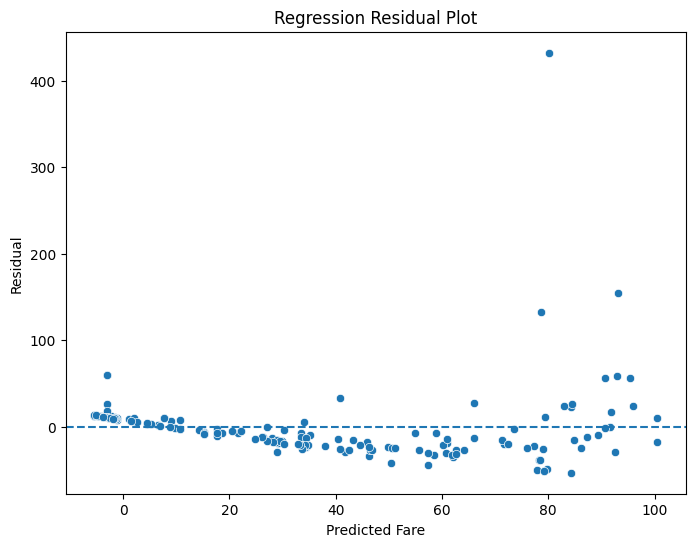

In [90]:
residuals = y_reg_test - y_reg_pred

plt.figure(figsize=(8, 6))

sns.scatterplot(
    x=y_reg_pred,
    y=residuals
)

plt.axhline(
    0,
    linestyle="--"
)

plt.xlabel("Predicted Fare")
plt.ylabel("Residual")
plt.title("Regression Residual Plot")

plt.show()

In [91]:
classification_results

,Model,Accuracy,Precision,Recall,F1,AUC
0,Logistic Regression,0.808989,0.783333,0.691176,0.734375,0.860963
1,Decision Tree,0.764045,0.760000,0.558824,0.644068,0.837366
2,Random Forest,0.808989,0.765625,0.720588,0.742424,0.819586


In [92]:
regression_results = pd.DataFrame({
    "Regression Model": ["Linear Regression"],
    "MAE": [mae],
    "RMSE": [rmse],
    "R2": [r2],
    "Adjusted R2": [adjusted_r2]
})

regression_results

,Regression Model,MAE,RMSE,R2,Adjusted R2
0,Linear Regression,21.098604,41.702105,0.348163,0.30913


Based on the test-set evaluation, the selected classifier provides a strong balance across accuracy, precision, recall, F1 score, and AUC. Its F1 score and AUC are particularly relevant because they summarize the model's ability to correctly classify survivors while considering both types of classification errors. The decision was based on the observed test-set metrics rather than training performance. The final selected model was then saved together with its preprocessing steps as a complete end-to-end pipeline.

Accuracy
Precision
Recall
F1
AUC

In [94]:
full_pipeline = best_rf_pipeline

In [95]:
joblib.dump(
    full_pipeline,
    "analytics/titanic_best_pipeline.joblib"
)

print("Complete pipeline saved successfully.")

Complete pipeline saved successfully.


In [96]:
loaded_pipeline = joblib.load(
    "analytics/titanic_best_pipeline.joblib"
)

print("Pipeline loaded successfully.")

Pipeline loaded successfully.


In [97]:
raw_test_sample = X_test.head(5)

loaded_predictions = loaded_pipeline.predict(
    raw_test_sample
)

print("Raw input:")
display(raw_test_sample)

print("\nPredictions:")
print(loaded_predictions)

Raw input:


,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,embark_town,alive,alone
160,3,male,44.0,0,1,16.100,S,Third,man,True,Southampton,no,False
126,3,male,28.0,0,0,7.750,Q,Third,man,True,Queenstown,no,True
428,3,male,28.0,0,0,7.750,Q,Third,man,True,Queenstown,no,True
422,3,male,29.0,0,0,7.875,S,Third,man,True,Southampton,no,True
565,3,male,24.0,2,0,24.150,S,Third,man,True,Southampton,no,False



Predictions:
[0 0 0 0 0]


In [98]:
readme = """
# Titanic Analytics Pipeline

## Overview

This module performs data profiling, cleaning, exploratory data analysis,
classification modeling, imbalance analysis, hyperparameter tuning,
regression analysis, and complete pipeline serialization.

## Dataset

The Titanic dataset was loaded once using Seaborn's built-in loader.
The original dataset was saved as titanic.csv for offline grading.

## Missing Values

Missing values were handled according to the assignment threshold rule.

## EDA

The analysis includes:
- Dataset profiling
- Missing-value analysis
- Age and fare distributions
- IQR-based outlier detection
- Survival analysis by sex
- Survival analysis by passenger class
- Survival analysis by sex and class
- Correlation heatmap
- Multivariate charts
- Standardization sanity check

## Classification

Three classifiers were trained:
- Logistic Regression
- Decision Tree
- Random Forest

All models used the same stratified train/test split and the preprocessing
steps were fitted only on the training data.

## Imbalance Handling

Baseline, class-weight-balanced, and SMOTE approaches were compared.

## Hyperparameter Tuning

Random Forest was tuned using GridSearchCV over:
- n_estimators
- max_depth
- max_features

OOB scoring was enabled.

## Regression

Linear regression was used to predict fare.

Metrics:
- MAE
- RMSE
- R²
- Adjusted R²

## Saved Model

The complete preprocessing and modeling pipeline was saved as:

titanic_best_pipeline.joblib
"""

with open(
    "analytics/README.md",
    "w"
) as f:
    f.write(readme)

print("README created.")

README created.


In [99]:
import os

for root, dirs, files in os.walk("analytics"):
    for file in files:
        print(os.path.join(root, file))

analytics/titanic_best_pipeline.joblib
analytics/titanic.csv
analytics/README.md
analytics/titanic_clean.csv


In [100]:
!zip -r analytics.zip analytics

  adding: analytics/ (stored 0%)
  adding: analytics/titanic_best_pipeline.joblib (deflated 76%)
  adding: analytics/titanic.csv (deflated 88%)
  adding: analytics/README.md (deflated 49%)
  adding: analytics/titanic_clean.csv (deflated 89%)


In [101]:
from google.colab import files

files.download("analytics.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>